In [29]:
!pip install textblob
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob

In [33]:
df_prep = pd.read_csv('telco_prep.csv')
df_results = pd.read_csv('sentiment_results.csv')

In [42]:
df_prep['customerID'] = df_prep['customerID'].str.upper()
df_results['customerID'] = df_results['customerID'].str.upper()

df_compare = pd.merge(
    df_prep[['customerID', 'Churn']],
    df_results[['customerID', 'Churn']],
    on='customerID',
    suffixes=('_prep', '_results')
)

In [43]:
df_compare['Churn_results'] = df_compare['Churn_results'].map({'Yes': 1, 'No': 0})

acc = accuracy_score(df_compare['Churn_prep'], df_compare['Churn_results'])
print(f"Data Alignment Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(df_compare['Churn_prep'], df_compare['Churn_results']))

Data Alignment Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5163
           1       1.00      1.00      1.00      1869

    accuracy                           1.00      7032
   macro avg       1.00      1.00      1.00      7032
weighted avg       1.00      1.00      1.00      7032



/tmp/ipykernel_522/1622401625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn_prep', data=df_compare, palette='viridis')


([<matplotlib.axis.XTick at 0x7a0290faade0>,
 [Text(0, 0, 'No Churn'), Text(1, 0, 'Churn')])

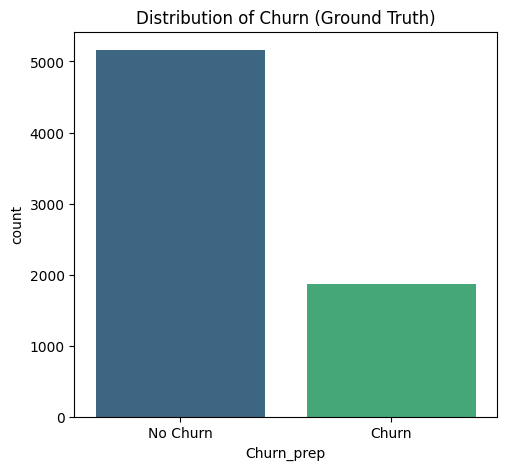

In [44]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Churn_prep', data=df_compare, palette='viridis')
plt.title('Distribution of Churn (Ground Truth)')
plt.xticks([0, 1], ['No Churn', 'Churn'])

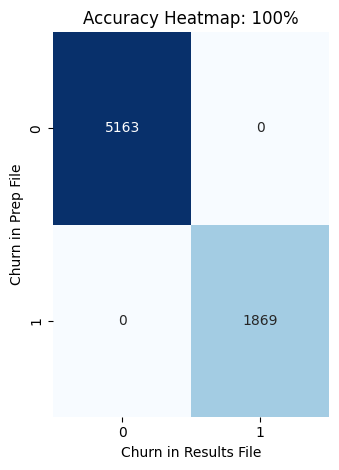

In [45]:
plt.subplot(1, 2, 2)
cm = confusion_matrix(df_compare['Churn_prep'], df_compare['Churn_results'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Churn in Results File')
plt.ylabel('Churn in Prep File')
plt.title(f'Accuracy Heatmap: {acc*100:.0f}%')

plt.tight_layout()
plt.show()